In [7]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os
import re
import time
import copy as cp
import argparse
import toml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import zeus

from scipy.interpolate import PchipInterpolator, CubicSpline

import alfred.utils as utils
import alfred.emulator as emulator
import alfred.KSZ as KSZ
import alfred.peefit as peefit
import alfred.surveys as surveys

import joblib
import keras
import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')

import warnings
from types import SimpleNamespace
from scipy.interpolate import RegularGridInterpolator, RectBivariateSpline
from catwoman.shelter import Cat

import alfred.surveys as surveys
import alfred.emulator as emulator
import alfred.utils as utils
from alfred.parameters import *
from alfred.astrofit import *

In [9]:

# # Set up argument parser
# parser = argparse.ArgumentParser(description="sets what experiment to use.")
# parser.add_argument("--survey", type=str, help="which survey to use")
# parser.add_argument("--savedir", type=str, help="where to save mcmcs")
# parser.add_argument("--nndir", type=str, help="which emulator runs to use")
# parser.add_argument("--version", type=str, help="which version of emulator")
# parser.add_argument("--overwrite", type=bool, help="whether or not to skip folders if existing")

# # Parse arguments
survey = 'CMB-HD'
savedir = 'productionruns_justpriors'
print('reading in database...')

validation_sims = np.load(f"{base_dir}/emulators/setrandomseed3/validation_sims.npy")
df_validation = df.loc[validation_sims].copy()

config = toml.load(f"{home_dir}/alfred/scripts/config_files/mcmc_config.toml")
config = SimpleNamespace(**config)
print(f"Now initialising mcmc run from config file {config.title}...")

config.savedir = f"{savedir}/{config.survey}"

noiseless = {'title': 'noiseless',
                'addnoise': False,
                'addPlanck': False}

noiseless_Planck = {'title': 'noiseless_Planck',
                'addnoise': False,
                'addPlanck': True}

addnoise = {'title': 'addnoise',
                'addnoise': True,
                'addPlanck': False}

addnoise_Planck = {'title': 'addnoise_Planck',
                'addnoise': True,
                'addPlanck': True}

setups = [noiseless, noiseless_Planck, addnoise, addnoise_Planck]

datapoints = utils.spectra(config.sn)[indices]
err_cov = surveys.error_cov(ells[indices],
                        datapoints,
                        surveys.telescopes[config.survey],
                        include_emulator=False)
err =np.sqrt(np.diag(err_cov))
noise = np.random.normal(scale=err)

reading in database...
Now initialising mcmc run from config file config...


<ErrorbarContainer object of 3 artists>

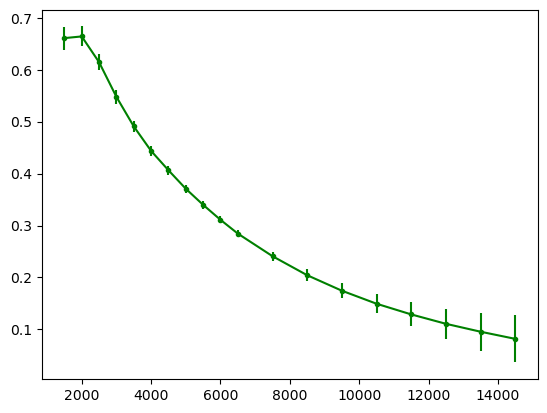

In [11]:
plt.errorbar(ells[indices], datapoints, yerr=err, marker='.', color='green')

In [15]:
#=================================================================
# RUNNING MCMC
#=================================================================
testing = True

if testing:
    config.burnin = 2
    config.nsteps = 100

mob = []
residuals_all = []
ratios_all = []

for n in range(5):
    print(f"Now on run {n}...")
    # if n != 0:
    #     continue
    config.emu_version = f"emuv5.1_run{n}"
    emu = summon_emu(f"{config.nndir}/{config.emu_version}", verbose=True)

    mob.append(emu)

    path_residuals = f'{base_dir}/emulators/{config.nndir}/{config.emu_version}/residuals.npy'
    path_ratios = f'{base_dir}/emulators/{config.nndir}/{config.emu_version}/ratios.npy'

    if os.path.exists(path_residuals):
        print(f'{path_residuals} already exists')
        residuals = np.load(path_residuals)
    else:
        print('creating residuals files...')
        emu = summon_emu(f"{config.nndir}/{config.emu_version}")
        tspec = np.zeros((len(validation_sims), len(ells[indices])))
        for i, sn in enumerate(df_validation.index):
            tspec[i] = utils.spectra(sn)[indices]

        espec = emulator.kemu(df_validation.to_numpy(), **emu)

        residuals = tspec - espec
        np.save(path_residuals, residuals)

        print(f"residuals file saved to {path_residuals}")
        print()
    
    residuals_all.append(residuals)
    
    if os.path.exists(path_ratios):
        print(f'{path_ratios} already exists')
        ratios = np.load(path_ratios)
    else:
        print('creating ratios file...')
        emu = summon_emu(f"{config.nndir}/{config.emu_version}")
        tspec = np.zeros((len(validation_sims), len(ells[indices])))
        for i, sn in enumerate(df_validation.index):
            tspec[i] = utils.spectra(sn)[indices]

        espec = emulator.kemu(df_validation.to_numpy(), **emu)

        ratios = tspec / espec
        np.save(path_ratios, ratios)

        print(f"ratios file saved to {path_ratios}")

        print()

    ratios_all.append(ratios)

residuals_all = np.asarray(residuals_all)
print(f"residuals shape is {residuals_all.shape}")
emu_error = np.std(residuals_all, axis=1)
print(f"emu error : {emu_error.shape}")
emu_error = np.mean(emu_error, axis=0)

print(f"emu error : {emu_error.shape}")

emuerr_file = f"{base_dir}/emulators/{config.nndir}/ensemble_error_v5.1.npy"
print(f"emu err: {emu_error.shape}")
print(f'saving average error file to {emuerr_file}...')
np.save(emuerr_file, emu_error)

ratios_all = np.asarray(ratios_all)
Amean = np.mean(ratios_all)
Asigma = np.std(ratios_all)
Ashape = np.mean(np.mean(ratios_all,axis=0), axis=0)

Now on run 0...
SUMMONING THE EMU!!! From /Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run0...
/Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run0/residuals.npy already exists
/Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run0/ratios.npy already exists
Now on run 1...
SUMMONING THE EMU!!! From /Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run1...
/Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run1/residuals.npy already exists
/Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run1/ratios.npy already exists
Now on run 2...
SUMMONING THE EMU!!! From /Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run2...
/Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run2/residuals.npy already exists
/Users/emcbride/Datasets/LoReLi/emulators/setrandomseed3/emuv5.1_run2/ratios.npy already exists
Now on run 3...
SUMMONING THE EMU!!! From /Users/emcbride/Datasets/LoR

title = noiseless
addnoise = False
addPlanck = False
-----------------------------------------
Now initialising MCMC class...
-----------------------------------------
Initialising from config file with settings:
title = noiseless
mcmc_dir = testing
sim_dir = ps_ee
Pee_dir = spectra/Pee
kSZ_dir = spectra/kSZ
fits_dir = lklhd_files
params_dir = param_files
ion_fn = metadata/ion_histories_full.npz
redshift_fn = metadata/redshift_list.dat
survey = CMB-HD
lmin = 1500
lmax = 10000
addnoise = False
use_data = True
sn = 12958
nndir = setrandomseed3
emu_version = emuv5.1_run4
nwalkers = 12
burnin = 2
nsteps = 100
rescale_cov = 0.1
add2d = True
addPlanck = False
vectorize = True
which_params = ['tau', 'Mmin', 'fesc']
Planck = 0.0576
Planck_err = 0.006
savedir = productionruns_justpriors/CMB-HD

using inputted emulator...

class initialisation complete!

-----------------------------------------
Now initialising data for MCMC run
-----------------------------------------
Using input data for dat

/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))


The value of the likelihood for the true params is: -0.0004197855438784942
fitting ell range [1500,9500]


Initialising ensemble of 12 walkers...



mcmc run initialisation complete!

Now starting MCMC run
-----------------------------------------
fitting ['tau', 'Mmin', 'fesc'] parameters...
fitting tau prior is False...
evaluating likelihood function in vector mode is True...
Okay, here we go!


...

The value of the likelihood for the true params is: -0.0004197855438784942
fitting ell range [1500,9500]

mcmc run initialisation complete!

Now starting MCMC run
-----------------------------------------
fitting ['tau', 'Mmin', 'fesc'] parameters...
fitting tau prior is True...
evaluating likelihood function in vector mode is True...
Okay, here we go!


/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
Sampling progress :   0%|                                                                      | 0/2 [00:00<?, ?it/s]/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.l

--------------------------------------------------------
Burn in phase took 0.116 minutes...
Starting proper run...
--------------------------------------------------------


Sampling progress :   0%|                                                                    | 0/100 [00:00<?, ?it/s]/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.log10(1), right=-10))
/Users/emcbride/alfred/src/alfred/keras_xe_emul.py:154: RuntimeWarning: divide by zero encountered in log10
  xe_fin =  10**(np.interp(np.log10(zvect), np.log10(x_vals[:,jmod]), np.log10(y_vals), left=np.l

finished MCMC in 0.07 hours
saving files in /Users/emcbride/Datasets/LoReLi/inference/productionruns_justpriors/CMB-HD/noiseless_Planck...
Done, YAY!



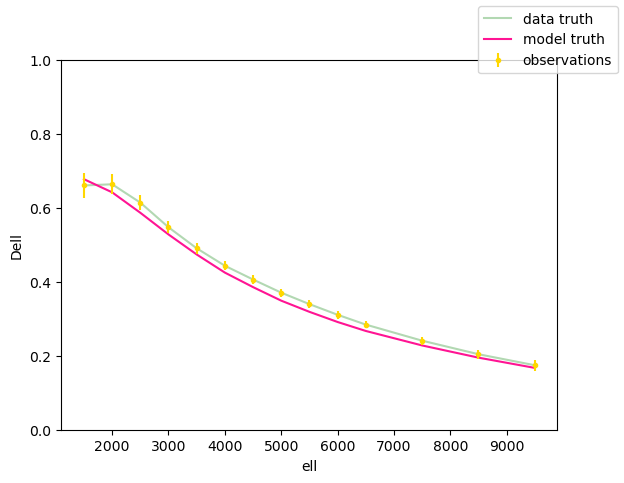

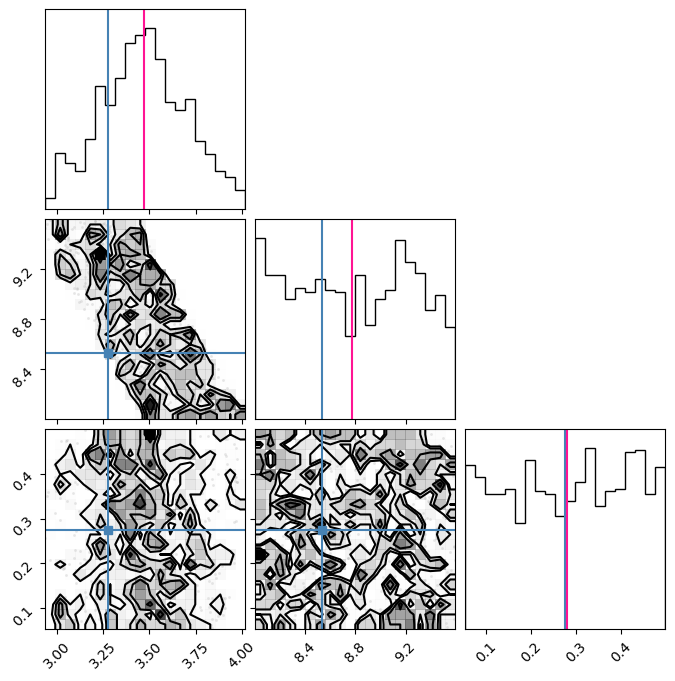

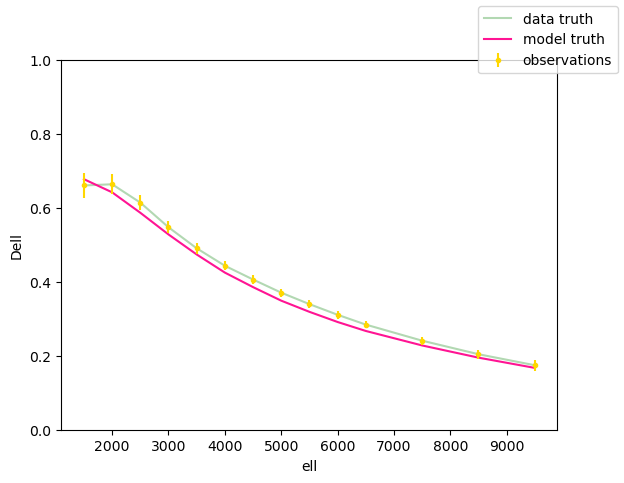

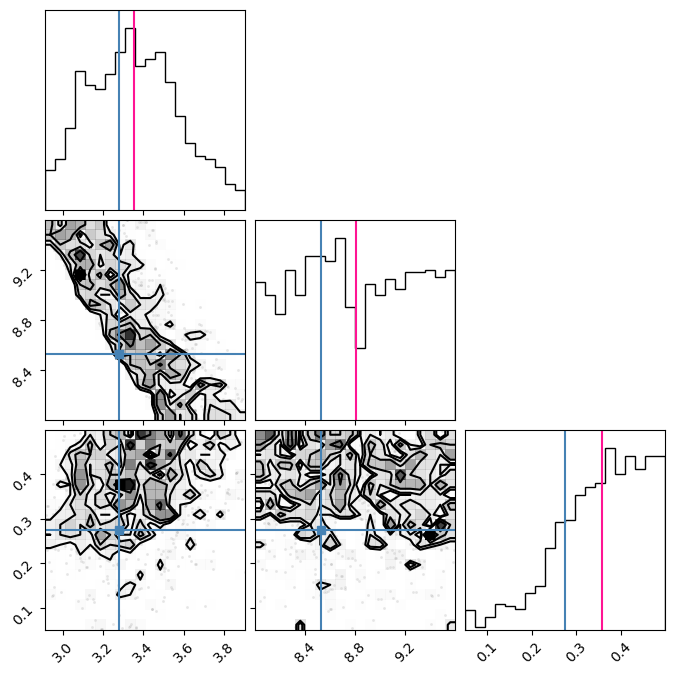

In [16]:
for i, setup in enumerate(setups[:2]):
    for key in setup.keys():
                print(f"{key} = {setup[key]}")
                setattr(config, key, setup[key])

    # if not args.overwrite:
    #      if os.path.exists(f"{config.savedir}/{config.title}"):
    #           print(f"Skipping run for {config.title}. Already exists and overwrite is {args.overwrite}")
    #           continue

    mcmc_run = MCMC(config,
                    ells=ells[indices],
                    p0=draws(ndraws=config.nwalkers)[:,2:], 
                    emu=mob,
                    emuerr_file=emuerr_file,
                    datapoints=datapoints,
                    A=np.random.uniform(.99,1.01, size=config.nwalkers),
                    Ashape=Ashape,
                    Astats=[Amean, Asigma],
                # dryrun=True,
                # showfigs=True,
                    Planck=whatthetau(df.loc[config.sn].to_numpy())[0],
                    justpriors=True,
                    verbose=True,
                    debug=False)

    mcmc_run.init_data()
    mcmc_run.init_run(savefig=True)
    sampler = mcmc_run.start_run(save=True)

    print()